# NOTEBOOK: Naive Bayes Classifier

 Goal: Implement and evaluate Naive Bayes Classifier

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data,
    plot_feature_distributions_by_class
)
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import SKLearnNaiveBayes, SKLearnLDA

from src.models.supervised.model_selection import (
    k_fold_cross_validation, 
    plot_cross_validation_results
)

2025-12-29 13:22:48.705897: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Loading & Exploration

DATA ANALYSIS

Dataset shape: 891 rows × 7 columns

Data types:
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

Missing values:
          Missing_Count  Missing_Percent
Age                 177            19.87
Embarked              2             0.22

Numerical columns (5):
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns (2):
['Sex', 'Embarked']

Numerical features statistics:
           Pclass         Age       SibSp       Parch        Fare
count  891.000000  714.000000  891.000000  891.000000  891.000000
mean     2.308642   29.699118    0.523008    0.381594   32.204208
std      0.836071   14.526497    1.102743    0.806057   49.693429
min      1.000000    0.420000    0.000000    0.000000    0.000000
25%      2.000000   20.125000    0.000000    0.000000    7.910400
50%      3.000000   28.000000    0.000000    0.000000   14.454200
75%      3.000000   38.000000    1

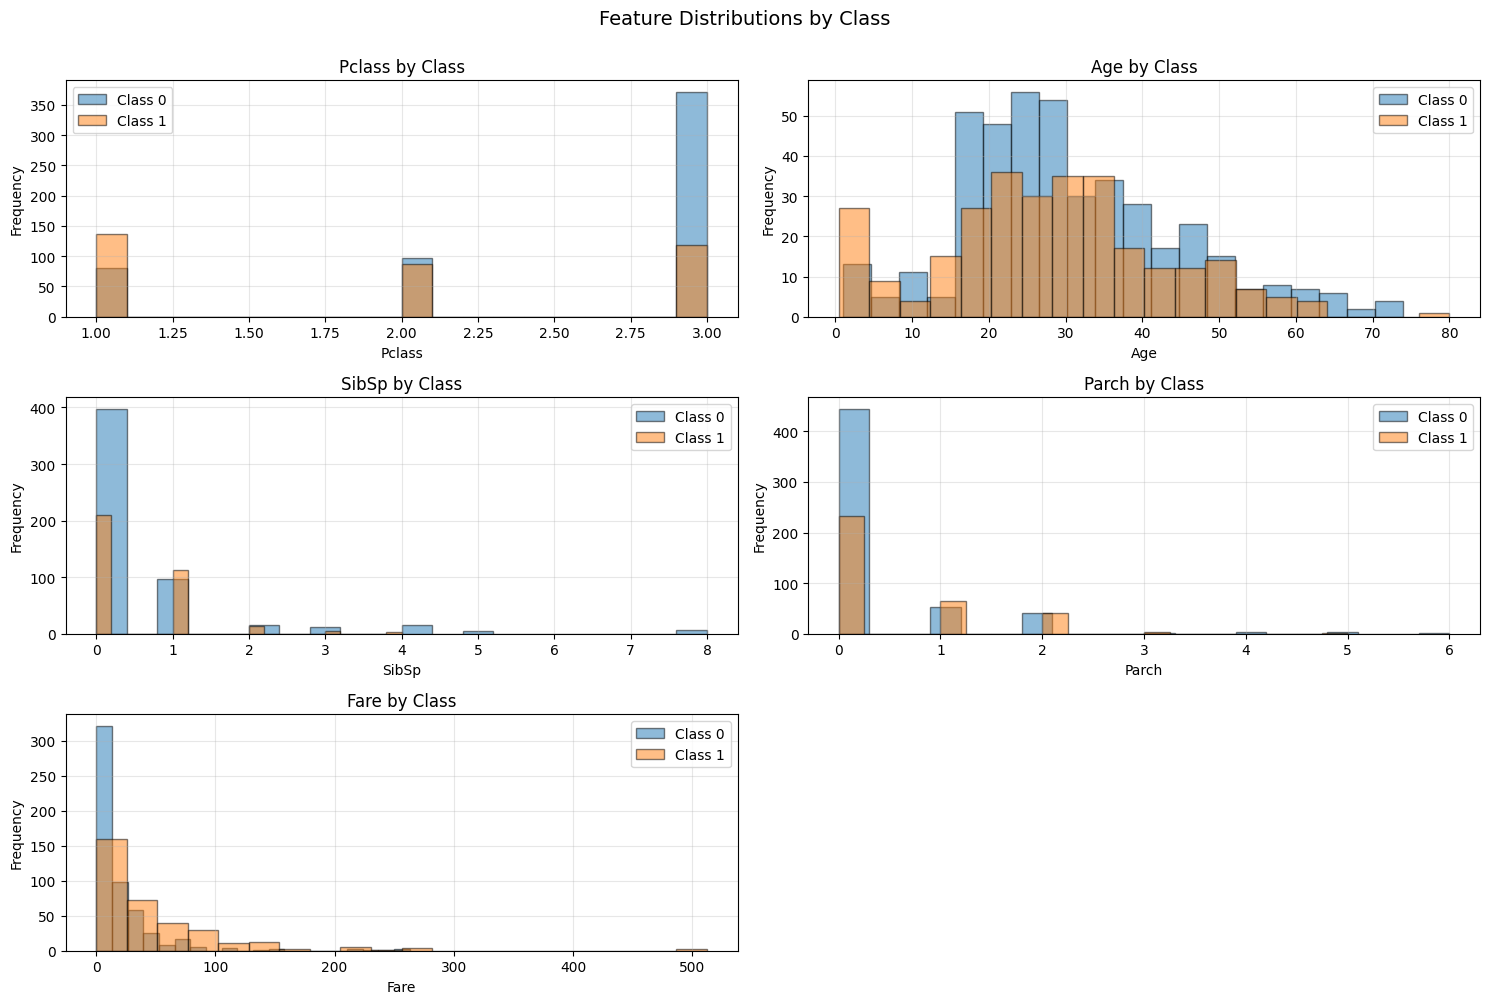

In [2]:
# Load data
# Quick EDA: shape, dtypes, missing values, class distribution
# Feature/target split

X, y = data_loader.load_titanic()

analyze_data(X, show_stats=True)
plot_feature_distributions_by_class(X, y)

## Preprocess Data

In [3]:


# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=True, encode_categorical=True)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Training set: {X_train_proc.shape}")
print(f"Test set: {X_test_proc.shape}")
print(f"\nFeature names after preprocessing:")
print(preprocessor.get_feature_names())


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 5 columns
   Nominal categorical: 2 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...
   ✓ Applied most_frequent imputation
   ✓ One-hot encoding 2 nominal columns...
   → Created 5 one-hot features

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 5 features

Final shape: 712 rows × 10 features

Training set: (712, 10)
Test set: (179, 10)

Feature names after preprocessing:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## Model Training

In [5]:
model = SKLearnNaiveBayes()
model.fit(X_train_proc, y_train)

print("✓ Model trained successfully")

✓ Model trained successfully


## Model Evaluation & Diagnostics


MODEL EVALUATION
Test Accuracy: 0.7765

Confusion Matrix:


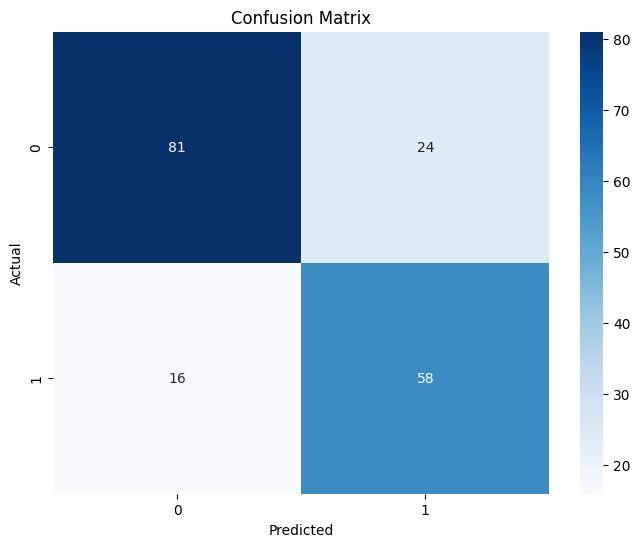


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       105
           1       0.71      0.78      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
test_accuracy = model.score(X_test_proc, y_test)

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nConfusion Matrix:")
cm = model.confusion_matrix(X_test_proc, y_test)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(model.classification_report(X_test_proc, y_test))

## K-Fold Cross-Validation for Robust Evaluation


K-FOLD CROSS-VALIDATION
K-FOLD CROSS-VALIDATION (k=5)
Task: Classification
Scoring: accuracy
Total samples: 712

Fold 1/5: accuracy=0.7692 (train: 569, test: 143)
Fold 2/5: accuracy=0.8112 (train: 569, test: 143)
Fold 3/5: accuracy=0.8239 (train: 570, test: 142)
Fold 4/5: accuracy=0.7606 (train: 570, test: 142)
Fold 5/5: accuracy=0.7887 (train: 570, test: 142)

CROSS-VALIDATION RESULTS
Mean accuracy: 0.7907 ± 0.0241
Min accuracy:  0.7606
Max accuracy:  0.8239


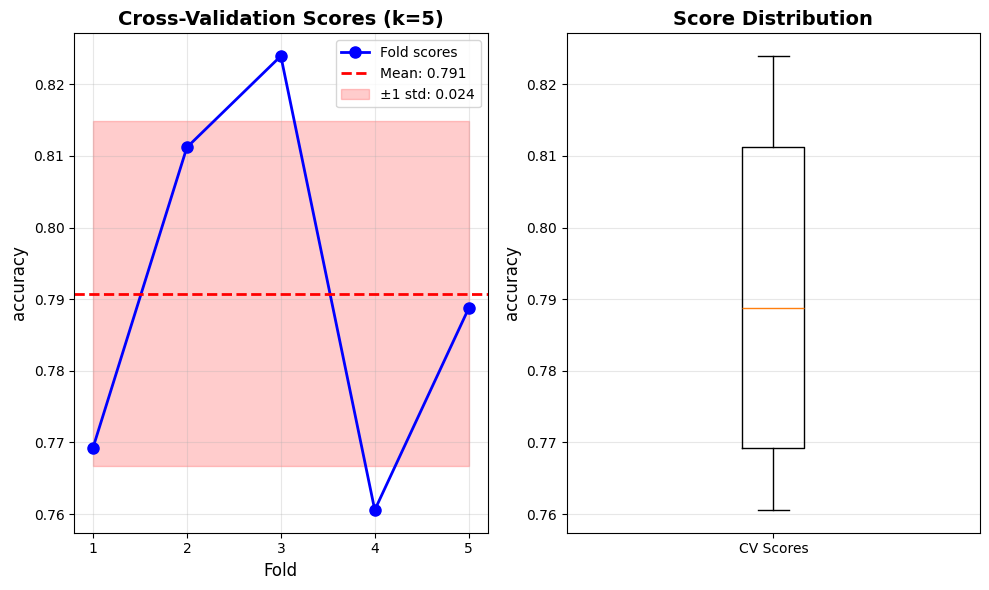


💡 Cross-validation provides more reliable estimate:
   Single test split: 0.7765
   5-fold CV: 0.7907 ± 0.0241


In [7]:
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION")
print("="*70)

# Perform 5-fold cross-validation
cv_results = k_fold_cross_validation(
    model=model,  # Use same model as before
    X=X_train_proc,
    y=y_train,
    k=5,
    scoring='accuracy'
)

# Visualize
plot_cross_validation_results(cv_results)

print(f"\n💡 Cross-validation provides more reliable estimate:")
print(f"   Single test split: {test_accuracy:.4f}")
print(f"   5-fold CV: {cv_results['mean']:.4f} ± {cv_results['std']:.4f}")

## Dimensionality Reduction Visualization


PCA vs LDA VISUALIZATION

⚠️  LDA Auto-adjustment:
   Requested n_components: 2
   Maximum allowed (n_classes - 1): 1
   Using: 1 component(s)

💡 Binary classification detected:
   LDA can only produce 1 component for 2 classes
   This finds the single best line to separate classes

PCA vs LDA VISUALIZATION
Number of classes: 2
PCA type: Linear PCA
PCA components: 2
LDA components: 1

💡 Binary classification: Showing scatter plots + histograms


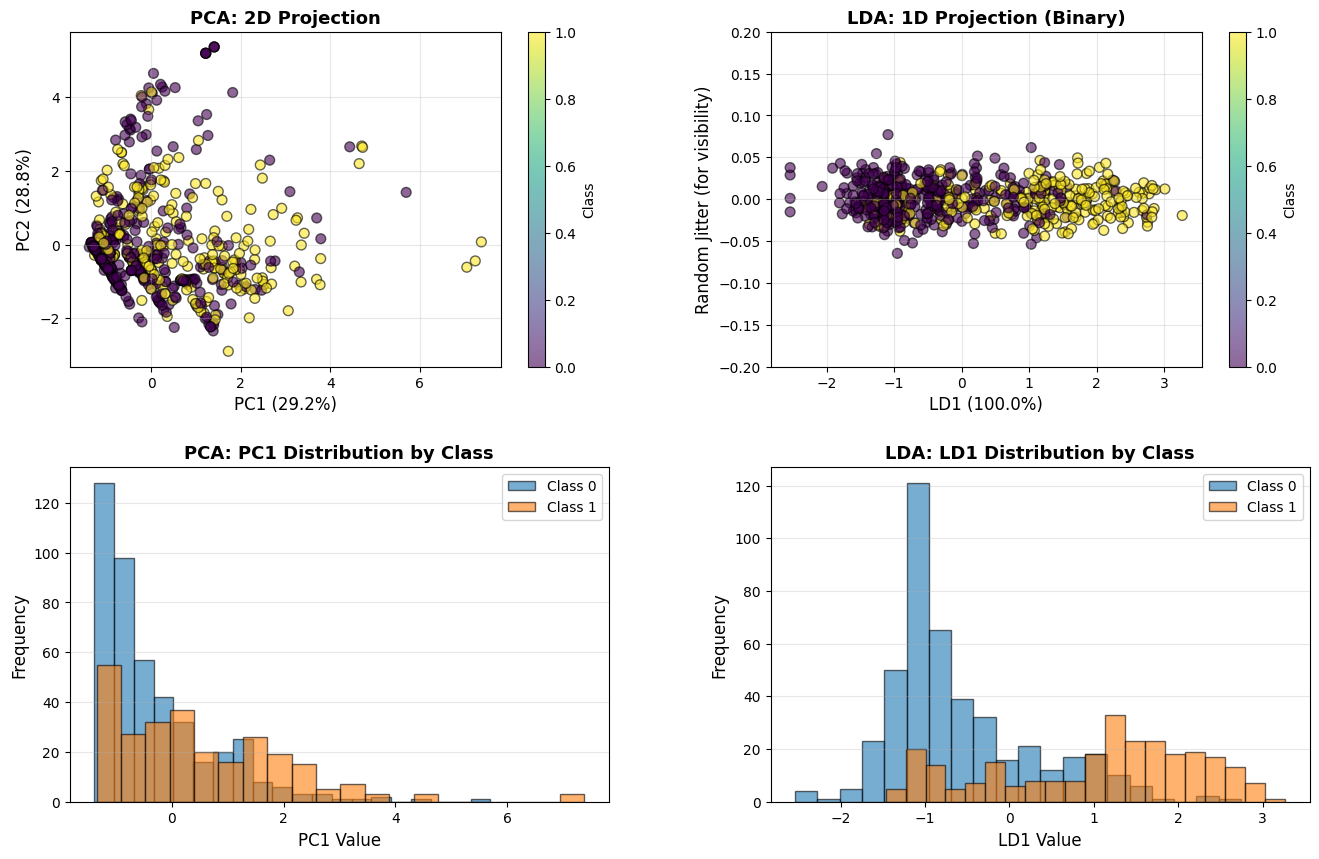


KEY INSIGHTS (Binary Classification)

💡 Why LDA only has 1 component:
   • For 2 classes, LDA can produce at most n_classes - 1 = 1 component
   • This finds the single best line to separate the two classes

💡 Notice in the histograms:
   • LDA (bottom right) shows better separation
   • PCA: Linear variance maximization
   • LDA: Supervised - maximizes class separation using labels

VARIANCE EXPLAINED

PCA: 58.0% total
  PC1: 29.2%
  PC2: 28.8%

LDA: 100.0% total
  LD1: 100.0%


In [8]:
print("\n" + "="*70)
print("PCA vs LDA VISUALIZATION")
print("="*70)

lda = SKLearnLDA(n_components=2)
lda.fit(X_train_proc, y_train)
lda.plot_comparison_with_pca(X_train_proc, y_train)

## Key Insights & Summary

In [9]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"\n✓ Model: {model.__class__.__name__}")
print(f"✓ Test Accuracy: {test_accuracy:.4f}")
print(f"✓ CV Accuracy: {cv_results['mean']:.4f} ± {cv_results['std']:.4f}")
print(f"\n💡 Model Performance:")
if test_accuracy >= 0.90:
    print("   Excellent performance (≥90%)")
elif test_accuracy >= 0.80:
    print("   Good performance (80-90%)")
elif test_accuracy >= 0.70:
    print("   Moderate performance (70-80%)")
else:
    print("   Room for improvement (<70%)")

print(f"\n💡 When to use {model.__class__.__name__}:")
if 'LogisticRegression' in str(model.__class__):
    print("   • Binary or multi-class classification")
    print("   • Need interpretable coefficients")
    print("   • Linear decision boundaries are sufficient")
    print("   • Fast training and prediction required")
elif 'NaiveBayes' in str(model.__class__):
    print("   • Text classification")
    print("   • Fast training required")
    print("   • Features are conditionally independent")
    print("   • Baseline model for comparison")


KEY INSIGHTS

✓ Model: SKLearnNaiveBayes
✓ Test Accuracy: 0.7765
✓ CV Accuracy: 0.7907 ± 0.0241

💡 Model Performance:
   Moderate performance (70-80%)

💡 When to use SKLearnNaiveBayes:
   • Text classification
   • Fast training required
   • Features are conditionally independent
   • Baseline model for comparison
